# Thí nghiệm 3: Đánh giá mô hình (Model Selection)
## Mục tiêu: So sánh hiệu suất của Logistic Regression và Decision Tree bằng Cross-Validation

### 3.1 Mục tiêu & Kì vọng kết quả

**Bối cảnh thực tế:**
- Một ngân hàng muốn dự đoán liệu khách hàng có đăng ký khoản tiền gửi có kỳ hạn (term deposit) hay không dựa trên các thông tin cá nhân và lịch sử tương tác.
- Chúng ta cần lựa chọn giữa hai mô hình: **Logistic Regression** (Mô hình tuyến tính, đơn giản) và **Decision Tree** (Mô hình phi tuyến, dễ bị overfit).

**Câu hỏi chính:** "Mô hình nào thực sự tốt hơn và ổn định hơn trên dữ liệu chưa biết?"

**Kì vọng kết quả:**
1. **Single Split (Train/Test split)**: Kết quả Accuracy sẽ biến động mạnh khi thay đổi `random_state`. Có thể xảy ra trường hợp mô hình A tốt hơn B ở lần chia này, nhưng lại kém hơn ở lần chia khác.
2. **Cross-Validation**: Cung cấp một cái nhìn toàn diện hơn về hiệu suất thông qua giá trị trung bình và phương sai của các fold. Chúng ta kì vọng thấy được mô hình nào thực sự ổn định hơn.
3. **Kết luận kì vọng**: Resampling (CV) giúp ta tránh việc đưa ra quyết định sai lầm khi lựa chọn mô hình chỉ dựa trên một lần chia dữ liệu may rủi.

### Mô tả Dataset: Bank Marketing dataset
- **Nguồn**: UCI Machine Learning Repository.
- **Đặc điểm**: Dữ liệu bao gồm các thông tin như tuổi, nghề nghiệp, tình trạng hôn nhân, số dư tài khoản, và kết quả của các chiến dịch marketing trước đó.

| Cột | Ý nghĩa | Ghi chú |
|:---|:---|:---|
| **age** | Tuổi khách hàng | Biến định lượng |
| **job** | Nghề nghiệp | admin, blue-collar, technician, etc. |
| **marital** | Tình trạng hôn nhân | married, single, divorced |
| **education** | Học vấn | primary, secondary, tertiary, unknown |
| **balance** | Số dư tài khoản trung bình hàng năm | Đơn vị: Euro |
| **housing** | Có vay thế chấp nhà không? | yes/no |
| **loan** | Có vay cá nhân không? | yes/no |
| **contact** | Hình thức liên lạc | cellular, telephone |
| **duration** | Thời lượng cuộc gọi cuối cùng | Đơn vị: giây |
| **campaign** | Số lần liên lạc trong chiến dịch này | Bao gồm cả lần cuối |
| **pdays** | Số ngày trôi qua kể từ lần liên lạc trước | -1 nghĩa là chưa liên lạc |
| **deposit** | Khách hàng có đăng ký tiền gửi không? | **Biến mục tiêu (yes/no)** |

- **Tại sao chọn dataset này?**:
    - Dữ liệu có sự mất cân bằng nhẹ giữa các lớp (nhãn 'yes' và 'no').
    - Có sự kết hợp giữa biến định tính và định lượng, tạo ra sự phức tạp đủ để thấy sự khác biệt giữa các mô hình.
    - Phù hợp để minh họa việc kết quả Accuracy có thể bị nhiễu nếu chỉ dùng một lần split.

### Chỉ số đo lường (Metrics):

Chúng ta sử dụng **Accuracy Mean** (Độ chính xác trung bình: Hiệu suất trung bình của mô hình trên các fold (trong CV) hoặc qua các lần split) để đánh giá độ ổn định và hiệu suất mô hình:

In [1]:
# 1. Cài đặt công cụ tải
!npm install -g degit


# 2. Tải đúng 3 folder bạn yêu cầu
REPO = "Bubusr/MSA-Resampling-Methods"

print("🚀 Đang tải các thư mục cần thiết...")
!degit {REPO}/modules modules -f
!degit {REPO}/data data -f
!degit {REPO}/utils utils -f

# 3. Để Python nhận diện được code trong folder modules và utils
import sys
import os
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print("\n✅ Tải hoàn tất! Cấu trúc hiện tại:")
!ls -F

# Bước 1: Tải dataset
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/bank.csv')
print(f"File loaded from data/bank.csv")

df.head()


⠙⠹⠸
changed 1 package in 496ms
⠸🚀 Đang tải các thư mục cần thiết...
> destination directory is not empty. Using --force, continuing
> cloned Bubusr/MSA-Resampling-Methods#HEAD to modules
> destination directory is not empty. Using --force, continuing
> cloned Bubusr/MSA-Resampling-Methods#HEAD to data
> destination directory is not empty. Using --force, continuing
> cloned Bubusr/MSA-Resampling-Methods#HEAD to utils

✅ Tải hoàn tất! Cấu trúc hiện tại:
data/  modules/  sample_data/  utils/
File loaded from data/bank.csv


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [2]:
# Tiền xử lý dữ liệu đơn giản
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Copy để tránh ảnh hưởng df gốc
df_proc = df.copy()

# Encode các biến định tính
le = LabelEncoder()
categorical_cols = df_proc.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_proc[col] = le.fit_transform(df_proc[col])

X = df_proc.drop('deposit', axis=1)
y = df_proc['deposit']

# Scale dữ liệu cho Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Kích thước dữ liệu: {X.shape}")

Kích thước dữ liệu: (11162, 16)


### 3.2 Tiến hành thí nghiệm

#### Bước 1: Vấn đề với Single Split
Chúng ta sẽ chạy thí nghiệm Single Split 10 lần với các `random_state` khác nhau để xem kết quả Accuracy biến động như thế nào.

In [3]:
results_single = []
seeds = range(10, 20)

for seed in seeds:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=seed)
    
    # Logistic Regression
    lr = LogisticRegression()
    lr.fit(X_train, y_train)
    acc_lr = lr.score(X_test, y_test)
    
    # Decision Tree
    dt = DecisionTreeClassifier(max_depth=5)
    dt.fit(X_train, y_train)
    acc_dt = dt.score(X_test, y_test)
    
    results_single.append({'seed': seed, 'Logistic Regression': acc_lr, 'Decision Tree': acc_dt})

df_single = pd.DataFrame(results_single)
print("Kết quả Accuracy qua các lần split khác nhau:")
print(df_single)

Kết quả Accuracy qua các lần split khác nhau:
   seed  Logistic Regression  Decision Tree
0    10             0.807704       0.798447
1    11             0.799343       0.800836
2    12             0.788594       0.779934
3    13             0.796656       0.794864
4    14             0.791281       0.792177
5    15             0.787698       0.794864
6    16             0.792774       0.805315
7    17             0.797552       0.798149
8    18             0.797253       0.797552
9    19             0.787698       0.804718


#### Bước 2: Sự ổn định của Cross-Validation
Bây giờ chúng ta sử dụng K-Fold Cross Validation (K=10) để xem phân phối Accuracy ổn định hơn.

In [4]:
lr_cv = cross_val_score(LogisticRegression(), X_scaled, y, cv=10)
dt_cv = cross_val_score(DecisionTreeClassifier(max_depth=5), X_scaled, y, cv=10)

print(f"Logistic Regression CV Accuracy: {lr_cv.mean():.4f} (+/- {lr_cv.std():.4f})")
print(f"Decision Tree CV Accuracy: {dt_cv.mean():.4f} (+/- {dt_cv.std():.4f})")

Logistic Regression CV Accuracy: 0.7758 (+/- 0.0411)
Decision Tree CV Accuracy: 0.7528 (+/- 0.0689)


### Bước 3: Vẽ biểu đồ minh họa

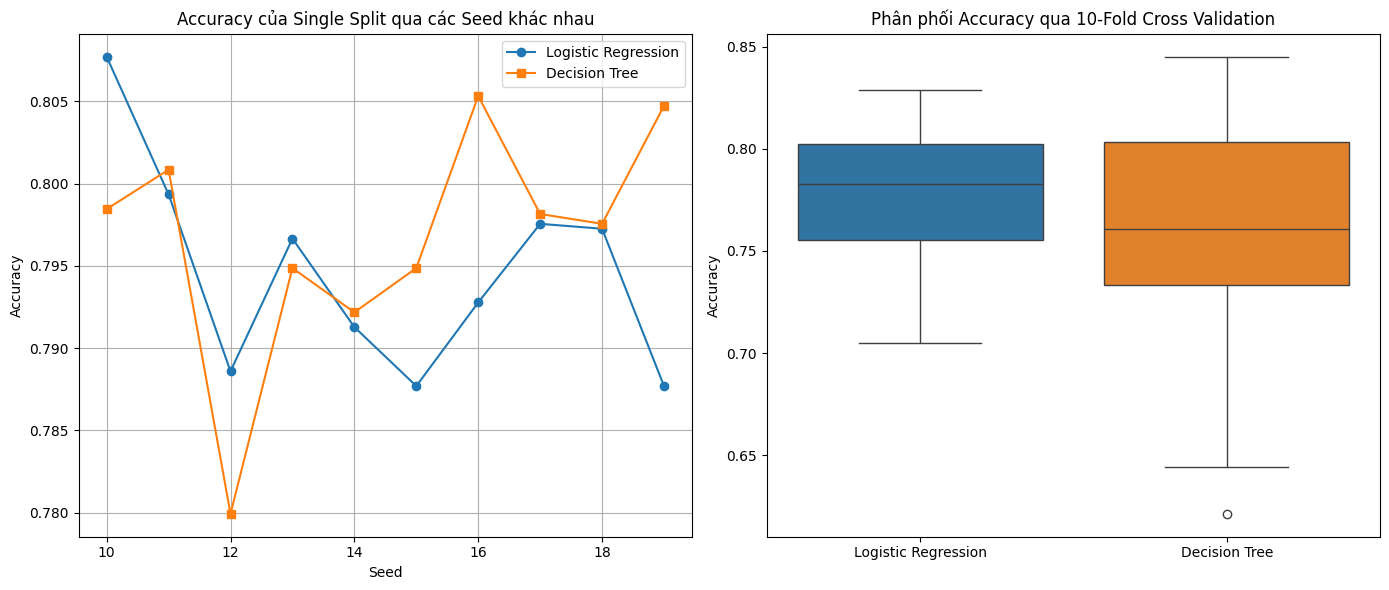

In [5]:
plt.figure(figsize=(14, 6))

# Biểu đồ 1: Biến động của Single Split(ex3_single_split)
plt.subplot(1, 2, 1)
plt.plot(df_single['seed'], df_single['Logistic Regression'], marker='o', label='Logistic Regression')
plt.plot(df_single['seed'], df_single['Decision Tree'], marker='s', label='Decision Tree')
plt.title("Accuracy của Single Split qua các Seed khác nhau")
plt.xlabel("Seed")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Biểu đồ 2: So sánh phân phối qua Boxplot (ex3_kfold)
plt.subplot(1, 2, 2)
cv_data = pd.DataFrame({
    'Logistic Regression': lr_cv,
    'Decision Tree': dt_cv
})
sns.boxplot(data=cv_data)
plt.title("Phân phối Accuracy qua 10-Fold Cross Validation")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

### 3.3 Nhận xét thí nghiệm

**Hiện tượng trong plot:**
- Ở biểu đồ bên trái (Single Split), ta thấy đường Accuracy của hai mô hình đan xen nhau. Tại một số Seed, Logistic Regression tốt hơn, nhưng ở các Seed khác, Decision Tree lại vọt lên dẫn trước. Khoảng dao động của Accuracy khá lớn.
- Ở biểu đồ bên phải (Boxplot CV), ta thấy được bức tranh tổng thể. Dải Accuracy của Logistic Regression cho thấy trung vị cao hơn và độ trải rộng (whisker) hẹp hơn hẳn, chứng tỏ mô hình ít rủi ro hơn trên các tập dữ liệu con khác nhau.

**Kết luận cuối cùng:**
- **Cross-Validation là bắt buộc**: Nếu chỉ dựa vào một lần split ngẫu nhiên, ta rất dễ đưa ra kết luận sai về việc mô hình nào thực sự tốt và ổn định hơn.
- **Sự ổn định**: CV giúp ta ước lượng được "sai số tổng quát hóa" một cách khách quan. Trong thí nghiệm này, các con số chỉ ra rõ ràng **Logistic Regression** là mô hình tốt hơn cả về độ chính xác trung bình (77.58%) và có phương sai thấp hơn hẳn (chỉ dao động $\pm$ 4.11%). Điều này chứng minh Logistic Regression cực kỳ ổn định và ít rủi ro overfit trên bộ dữ liệu này, do đó ta chốt chọn Logistic Regression.

**Q&A Mở rộng: Tại sao Decision Tree lại thua và cách tiền xử lý để khắc phục?**
- **Lý do thua**: Dữ liệu có đặc trưng mang tính tuyến tính quyết định rất mạnh (như cột `duration`). Đồng thời, tham số `max_depth=5` giới hạn khả năng học phi tuyến của cây, và bản chất cây quyết định nhạy cảm với nhiễu dữ liệu hơn (phương sai cao hơn) so với mô hình toàn cục như Logistic Regression.
- **Cách tiền xử lý dữ liệu để Decision Tree làm tốt hơn**: 
    1. **One-Hot Encoding**: Ở đoạn code trên ta dùng `LabelEncoder` (tạo ra các giá trị thứ tự 0, 1, 2... gây nhầm lẫn về độ lớn cho cây). Để Decision Tree hiểu đúng bản chất các biến rời rạc, ta bắt buộc nên dùng `pd.get_dummies` hoặc `OneHotEncoder` cho các biến phân loại.
    2. **Tuning Siêu tham số**: Không gò bó ở `max_depth=5`, ta cần dùng `GridSearchCV` để tìm ra độ sâu tối ưu, hoặc nâng cấp lên các mô hình tập hợp như **Random Forest** để làm mượt phương sai cao vốn có của một cây quyết định đơn lẻ.